<hr style="border:2px solid #CC00FF;">

<!-- Contenedor ultra-compatible. Usamos 'height' en lugar de 'width' para lograr simetría visual -->
<p align="center">
    <a href="https://medellin.unal.edu.co" target="_blank">
        <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR9ItLTT_F-3Q30cu7ZCCoKmuFGBt22pe7pNA" height="75" alt="Logo UNAL">
    </a>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
    <a href="https://minaslap.net/?redirect=0" target="_blank">
        <img src="https://minaslap.net/pluginfile.php/1/core_admin/logo/0x200/1770226238/Logo%20MinasLAP-3%20%281%29.png" height="75" alt="Logo MinasLAP">
    </a>
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
    <a href="https://micampus.unal.edu.co" target="_blank">
        <img src="https://micampus.unal.edu.co/pluginfile.php/1/theme_almondb/sliderimage1/1788871931/Slider_1.png" height="75" alt="Logo MiCampus">
    </a>
</p>

<!-- Títulos usando alineación clásica compatible con IDEs -->
<h1 align="center">Optimización e IA 2026-2S</h1>
<h2 align="center">Práctica 2</h2>
<h3 align="center">Parte 1: Selección del problema</h3>
<p align="center">
    Departamento de Ciencias de la Computación y de la Decisión<br>
    Facultad de Minas<br>
    Universidad Nacional de Colombia<br>
    Docente: Maria Constanza Torres Madronero
</p>

<div id="conte"></div>
<hr style="border:2px solid #CC00FF;">

**Elaborado por:** _Kevin Ferney Hidalgo Higuita_

**Correo:** _kfhidalgoh@unal.edu.co_

**Fecha de elaboración:** _28 de septiembre de 2026_

**Fecha última modificación:** _28 de septiembre de 2026_

**Repositorio:** [![GitHub Repository](https://img.shields.io/badge/repository-GitHub-181717.svg)](https://github.com/KevinHidalgoDS/optimizacion-ia)

*Nota: el tema del navegador para visualizar HTML puede afectar el comportamiento de la presentación.*

In [1]:
import sys

# import matplotlib.pyplot as plt
from pathlib import Path

import numpy as np
import pandas as pd
from src.graph.fun_graph_matplotlib import FnGraphMat
from src.utils import lecturaExcel as lE
from src.utils import logger as log
from src.utils.statisticsBase import column_overview, detectar_outliers, numeric_descriptive_stats

logger = log.LOGGER
config = log.CONFIG
logger.info("Python %s on %s", sys.version, sys.platform)

# %matplotlib inline
grmt = FnGraphMat('seaborn-v0_8-darkgrid')
rng = np.random.default_rng(123)

2026-09-28 22:38:35 [INFO] Python 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)] on win32


Seleccione uno de los siguientes datasets para la presentación de la práctica 2.

- CIFAR100: Este conjunto de datos incluye 50,000 imágenes 32x32 para entrenamiento, 10,000 imágenes para evaluación. Vamos a trabajar con 20 clases (label_mode: “coarse”). La base de datos se encuentra disponible en la librería Keras:
    ```text
    (x_train, y_train), (x_test, y_test) =
    tf.keras.datasets.cifar100.load_data(label_mode="coarse")
    ```
- House prices: incluida como archivo adjunto en el moodle.

De acuerdo con la selección del conjunto de datos, su problema será el de clasificación (CIFAR100) o de regresión (House prices).

## Lectura de `house_prices.csv`

In [2]:
file_path = Path(config.paths.data.raw) / "house_prices.csv"
if not file_path.exists():
    from src.config import PROJECT_PATH
    file_path = PROJECT_PATH / config.paths.data.raw / "house_prices.csv"

logger.info("Leyendo archivo desde: %s", file_path)
df = pd.read_csv(file_path)
logger.info("Archivo cargado exitosamente con dimensiones: %s", df.shape)

list_df = [df]

for i in list_df:
    lE.normalizar_columnas_snake_case(i, inplace=True)

2026-09-28 22:38:35 [INFO] Leyendo archivo desde: D:\Proyectos\optimizacion-ia\data\raw\house_prices.csv
2026-09-28 22:38:35 [INFO] Archivo cargado exitosamente con dimensiones: (1460, 20)


In [3]:
df.head()

,id,grlivarea,yearbuilt,yearremodadd,1stflrsf,2ndflrsf,hasbasement,totalbsmtsf,garage,garagearea,garagecars,kitchenqual,totrmsabvgrd,bedroomabvgr,totalbathrooms,overallqual,numfloors,poolqc,pool,saleprice
0,1,1710,2003,2003,856,854,Yes,856,Yes,548,2,Gd,8,3,3.5,7,2,No Pool,No,208500
1,2,1262,1976,1976,1262,0,Yes,1262,Yes,460,2,TA,6,3,2.5,6,1,No Pool,No,181500
2,3,1786,2001,2002,920,866,Yes,920,Yes,608,2,Gd,6,3,3.5,7,2,No Pool,No,223500
3,4,1717,1915,1970,961,756,Yes,756,Yes,642,3,Gd,7,3,2.0,7,2,No Pool,No,140000
4,5,2198,2000,2000,1145,1053,Yes,1145,Yes,836,3,Gd,9,4,3.5,8,2,No Pool,No,250000


## Transformaciones

In [4]:
kitchen_quality_mapping = {
    "Ex": 5,  # Excellent
    "Gd": 4,  # Good
    "TA": 3,  # Typical / Average
    "Fa": 2,  # Fair
    "Po": 1,  # Poor
}

# Aplicar mapeo a la columna KitchenQual
df["kitchenqual"] = df["kitchenqual"].map(kitchen_quality_mapping)

df["kitchenqual"].head()

0    4
1    3
2    4
3    4
4    4
Name: kitchenqual, dtype: int64

In [5]:
pool_qc_mapping = {
    "No Pool": 0,
    "Fa": 1,  # Fair
    "TA": 2,  # Typical / Average
    "Gd": 3,  # Good
    "Ex": 4,  # Excellent
}

df["poolqc"] = df["poolqc"].fillna("No Pool").map(pool_qc_mapping)

df["poolqc"].head()

0    0
1    0
2    0
3    0
4    0
Name: poolqc, dtype: int64

In [6]:
binary_mapping = {"Yes": 1, "No": 0}

for col in ["hasbasement", "garage", "pool"]:
    if col in df.columns:
        df[col] = df[col].map(binary_mapping)

In [7]:
df.loc[:, ["hasbasement", "garage", "pool"]].head()

,hasbasement,garage,pool
0,1,1,0
1,1,1,0
2,1,1,0
3,1,1,0
4,1,1,0


In [8]:
column_overview(df)

,dtype,missing_count,unique_count
id,int64,0,1460
grlivarea,int64,0,861
yearbuilt,int64,0,112
yearremodadd,int64,0,61
1stflrsf,int64,0,753
2ndflrsf,int64,0,417
hasbasement,int64,0,2
totalbsmtsf,int64,0,721
garage,int64,0,2
garagearea,int64,0,441


In [9]:
numeric_descriptive_stats(df)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max,median,missing
id,1460.0,730.500000,421.610009,1.0,15.59,73.95,146.9,365.75,730.5,1095.25,1314.1,1387.05,1445.41,1460.0,730.5,0
grlivarea,1460.0,1515.463699,525.480383,334.0,692.18,848.00,912.0,1129.50,1464.0,1776.75,2158.3,2466.10,3123.48,5642.0,1464.0,0
yearbuilt,1460.0,1971.267808,30.202904,1872.0,1899.18,1916.00,1924.9,1954.00,1973.0,2000.00,2006.0,2007.00,2009.00,2010.0,1973.0,0
yearremodadd,1460.0,1984.865753,20.645407,1950.0,1950.00,1950.00,1950.0,1967.00,1994.0,2004.00,2006.0,2007.00,2009.00,2010.0,1994.0,0
1stflrsf,1460.0,1162.626712,386.587738,334.0,520.00,672.95,756.9,882.00,1087.0,1391.25,1680.0,1831.25,2219.46,4692.0,1087.0,0
2ndflrsf,1460.0,346.992466,436.528436,0.0,0.00,0.00,0.0,0.00,0.0,728.00,954.2,1141.05,1418.92,2065.0,0.0,0
hasbasement,1460.0,0.974658,0.157217,0.0,0.00,1.00,1.0,1.00,1.0,1.00,1.0,1.00,1.00,1.0,1.0,0
totalbsmtsf,1460.0,1057.429452,438.705324,0.0,0.00,519.30,636.9,795.75,991.5,1298.25,1602.2,1753.00,2155.05,6110.0,991.5,0
garage,1460.0,0.944521,0.228992,0.0,0.00,0.00,1.0,1.00,1.0,1.00,1.0,1.00,1.00,1.0,1.0,0
garagearea,1460.0,472.980137,213.804841,0.0,0.00,0.00,240.0,334.50,480.0,576.00,757.1,850.10,1002.79,1418.0,480.0,0


In [10]:
detectar_outliers(df, variable_target='saleprice')


=== DETECCIÓN DE OUTLIERS (MÉTODO IQR) ===

--- saleprice ---
Límites IQR: [3937.50, 340037.50]
Outliers detectados: 61 (4.18%)
Valores outliers: [345000 385000 438780 383970 372402 412500 501837 475000 386250 403000
 415298 360000 375000 342643 354000 377426 437154 394432 426000 555000
 440000 380000 374000 430000 402861 446261 369900 451950 359100 345000
 370878 350000 402000 423000 372500 392000 755000 361919 341000 538000
 395000 485000 582933 385000 350000 611657 395192 348000 556581 424870
 625000 392500 745000 367294 465000 378500 381000 410000 466500 377500
 394617]


{'outliers': 11      345000
 53      385000
 58      438780
 112     383970
 151     372402
          ...  
 1268    381000
 1353    410000
 1373    466500
 1388    377500
 1437    394617
 Name: saleprice, Length: 61, dtype: int64,
 'limite_inferior': np.float64(3937.5),
 'limite_superior': np.float64(340037.5),
 'count': 61,
 'porcentaje': 4.178082191780822}

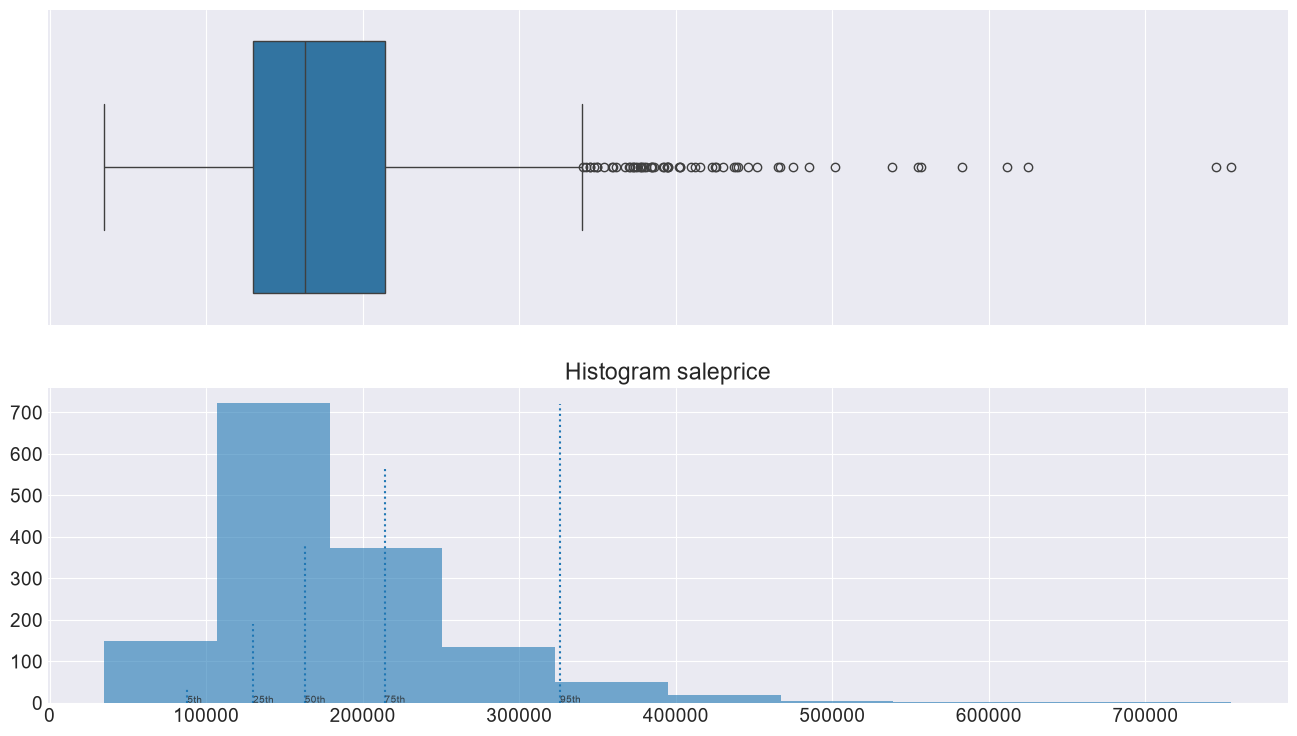

In [11]:
grmt.graph_armor_hist(df, 'saleprice')

In [12]:
file_path = Path(config.paths.data.processed) / "house_prices.csv"
if not file_path.exists():
    from src.config import PROJECT_PATH
    file_path = PROJECT_PATH / config.paths.data.processed / "house_prices.csv"

logger.info("Guardando archivo procesado: %s", file_path)
df.to_csv(file_path, index=False)
logger.info("Archivo cargado exitosamente con dimensiones: %s", df.shape)

2026-09-28 22:38:41 [INFO] Guardando archivo procesado: D:\Proyectos\optimizacion-ia\data\processed\house_prices.csv
2026-09-28 22:38:41 [INFO] Archivo cargado exitosamente con dimensiones: (1460, 20)
